# 01 - Data Acquisition

This notebook rebuilds the raw dataset from the public GeoNet APIs. Nothing is
read from a pre-prepared file, so the whole thing can be reconstructed from
scratch by anyone with an internet connection.

Two endpoints are used:

- `quakesearch.geonet.org.nz/geojson` for the earthquake catalogue
- `api.geonet.org.nz/intensity` for Felt RAPID Report submissions

Responses are cached under `data/raw`, so re-running this notebook does not hit
the API again.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd

import ingest

pd.set_option("display.width", 120)

## The catalogue

GeoNet publishes every located event. The window used here is magnitude 4.0 to
8.0 between October 2016 and December 2025, which is the same period the
original study covered.

In [2]:
raw_events = ingest.fetch_events(4.0, 8.0, "2016-10-01T00:00:00", "2025-12-31T23:59:59")
print(f"{len(raw_events):,} entries returned by the catalogue")
raw_events.head()

14,182 entries returned by the catalogue


,public_id,origin_time,magnitude,depth_km,longitude,latitude
0,2016p740609,2016-10-01 00:33:15.933000+00:00,5.016511,33.000000,-173.328598,-25.831463
1,2016p741048,2016-10-01 04:25:42.668000+00:00,4.716573,573.491821,-178.664688,-23.817320
2,2016p741242,2016-10-01 06:13:03.177000+00:00,4.260203,248.891663,-179.876801,-30.528933
3,2016p741634,2016-10-01 09:37:59+00:00,4.438518,63.000000,166.520000,-12.530000
4,2016p742781,2016-10-01 19:52:12.182000+00:00,4.609051,39.302265,-176.104645,-28.805132


## Two problems with the raw catalogue

The catalogue is not a list of New Zealand earthquakes. It is a list of events
New Zealand instruments detected, which is a different thing.

Querying a single month returns earthquakes in Chile and Japan. Those are real
events, but a hypocentral distance measured from Fukushima to Christchurch is
not a meaningful predictor of shaking felt here.

There are also repeated entries for the same physical earthquake, differing
only in their magnitude solution.

In [3]:
november = ingest.fetch_events(6.0, 8.0, "2016-11-01T00:00:00", "2016-11-30T00:00:00")
november[["public_id", "origin_time", "magnitude", "longitude", "latitude"]]

,public_id,origin_time,magnitude,longitude,latitude
0,2016p858000,2016-11-13 11:02:56.346000+00:00,7.820380,173.022141,-42.692535
1,2016p858007,2016-11-13 11:05:14.415000+00:00,6.024825,173.700989,-41.968750
2,2016p858021,2016-11-13 11:12:35.486000+00:00,6.026433,173.776901,-42.428482
3,2016p858055,2016-11-13 11:32:07+00:00,6.183157,173.672775,-42.246460
4,2016p858094,2016-11-13 11:52:44.351000+00:00,6.136440,173.602631,-42.201073
5,2016p859524,2016-11-14 00:34:23.359000+00:00,6.656748,173.137573,-42.465363
6,2016p878059,2016-11-20 20:57:43+00:00,6.374588,-68.764000,-31.643000
7,2016p880765,2016-11-21 20:59:49+00:00,6.686873,141.387000,37.393000
8,2016p880766,2016-11-21 20:59:49+00:00,6.910880,141.387000,37.393000
9,2016p880764,2016-11-21 20:59:49+00:00,6.811184,141.387000,37.393000


Above, `2016p878059` sits at longitude -68.8, latitude -31.6, which is Chile.
The three entries ending 880764, 880765 and 880766 share an origin time and a
location off Fukushima, differing only in magnitude.

Worth being precise about which step does the work. The New Zealand filter
removes all four of those entries, because the duplicates in this window are
themselves teleseismic. Deduplication then removes nothing at all: after
filtering, no two entries share an origin time and location. It is kept as a
guard rather than counted as a finding, because a different date range could
put duplicates inside the New Zealand box and training on the same earthquake
twice would be worse than an inert filter.

The bounding box is deliberately split across the antimeridian, because the
Chatham Islands sit just past 180 degrees and a naive 165 to 180 box would
discard them.

In [4]:
events = ingest.drop_duplicate_events(ingest.filter_to_new_zealand(raw_events))

print(f"raw catalogue        {len(raw_events):>7,}")
print(f"after NZ filter      {len(ingest.filter_to_new_zealand(raw_events)):>7,}")
print(f"after deduplication  {len(events):>7,}")
print(f"removed              {len(raw_events) - len(events):>7,} "
      f"({100 * (1 - len(events) / len(raw_events)):.0f}% of the raw catalogue)")

raw catalogue         14,182
after NZ filter        3,908
after deduplication    3,908
removed               10,274 (72% of the raw catalogue)


Almost three quarters of the raw catalogue is unusable for this problem. That
is worth knowing before trusting any count of "New Zealand earthquakes" taken
straight from the API.

## Why the selection has to be stratified

Earthquake magnitudes follow a power law: small events are overwhelmingly more
common than large ones. Sampling the catalogue at random would produce a
dataset that is almost entirely small earthquakes, and the model would rarely
see the strong shaking it most needs to predict.

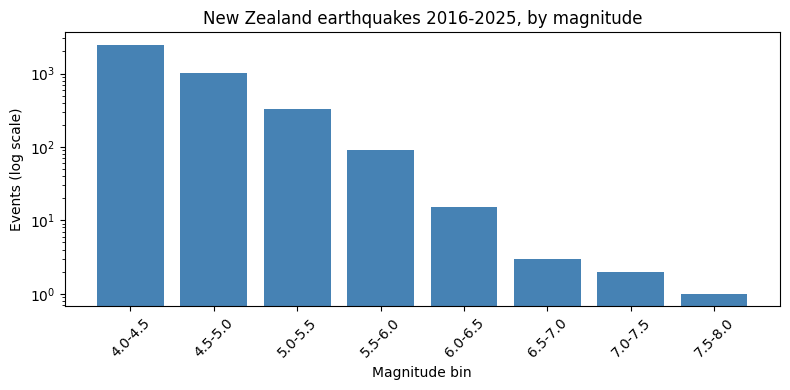

,magnitude_bin,events
0,4.0-4.5,2462
1,4.5-5.0,1009
2,5.0-5.5,324
3,5.5-6.0,92
4,6.0-6.5,15
5,6.5-7.0,3
6,7.0-7.5,2
7,7.5-8.0,1


In [5]:
binned = ingest.assign_magnitude_bins(events)
counts = ingest.summarise_bins(binned)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(counts["magnitude_bin"], counts["events"], color="steelblue")
ax.set_yscale("log")
ax.set_xlabel("Magnitude bin")
ax.set_ylabel("Events (log scale)")
ax.set_title("New Zealand earthquakes 2016-2025, by magnitude")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

counts

Note the log scale: there are more than two thousand events in the smallest bin
and a single one above magnitude 7.5, the 2016 Kaikoura earthquake.

Sampling evenly across bins corrects for this. Bins holding fewer events than
the cap contribute everything they have, so the result is as balanced as the
catalogue allows.

## Fetching felt reports

Each event's felt reports are fetched separately. GeoNet aggregates individual
public submissions to points before publishing, and crucially each point
carries `count_mmi`: the full distribution of intensities reported there, not
just a summary. Keeping that distribution is what allows the choice of central
tendency measure to be made later rather than being fixed here.

In [6]:
events, felt = ingest.build_dataset()

catalogue returned 14182 events
3908 remain after removing teleseismic and duplicate entries
261 sampled across magnitude bins


[2023p707798] dropped 4 out-of-scale reports (MMI 1: 2, MMI 2: 2)
[2023p728259] dropped 1 out-of-scale reports (MMI 1: 1)
[2024p260656] dropped 1 out-of-scale reports (MMI 1: 1)
[2025p224518] dropped 1 out-of-scale reports (MMI 1: 1)
99 events cleared the 100 report threshold
144853 reporting locations, 609476 felt reports in total


## Balancing events does not balance data

This is the finding that matters most from this notebook. Stratifying by
magnitude balances the number of earthquakes per bin. It does not balance the
amount of data, because small earthquakes generate almost no felt reports.

In [7]:
yield_by_bin = (
    felt.groupby("public_id")["report_count"].sum()
    .to_frame("reports")
    .join(events.set_index("public_id")[["magnitude", "magnitude_bin"]])
    .groupby("magnitude_bin")
    .agg(events=("reports", "size"), median_reports=("reports", "median"),
         total_reports=("reports", "sum"))
    .astype(int)
)
yield_by_bin

,events,median_reports,total_reports
magnitude_bin,,,
4.0-4.5,13,268,12392
4.5-5.0,18,1059,46758
5.0-5.5,19,1832,85184
5.5-6.0,35,4850,312789
6.0-6.5,8,6801,60278
6.5-7.0,3,4725,14771
7.0-7.5,2,30732,61464
7.5-8.0,1,15840,15840


A handful of large earthquakes contribute the overwhelming majority of the
reports. Any claim that this dataset is "balanced across magnitudes" is true
only in a narrow sense, and that caveat carries through to every result built
on it.

## A third data quality problem

The Felt RAPID Report survey presents six cartoons corresponding to MMI 3
through 8, so no other value should exist. A handful of MMI 1 and 2 reports do
appear in the archive. They are dropped during ingestion, with the affected
events named rather than removed silently, and `report_count` is recomputed
from the levels actually kept.

## Result

In [8]:
print(f"events   {len(events):>8,}")
print(f"locations{len(felt):>8,}")
print(f"reports  {int(felt['report_count'].sum()):>8,}")

events.to_csv("../data/processed/events.csv", index=False)
felt.to_csv("../data/processed/felt_reports.csv", index=False)
print("\nwritten to data/processed/")

events         99
locations 144,853
reports   609,476



written to data/processed/


## Summary

- The raw catalogue needed heavy filtering: 72% of entries were teleseismic,
  detected in New Zealand rather than occurring here. Duplicate magnitude
  solutions exist too, but only among those teleseismic entries, so the
  deduplication step currently removes nothing.
- Selection is stratified across magnitude bins because the catalogue follows a
  power law, but this balances events rather than data volume.
- Felt report distributions are preserved rather than collapsed, so the target
  definition stays open.

Next: `02_exploratory_analysis.ipynb` aggregates these reports onto a grid and
examines what they actually show.